In [ ]:
from google.colab import files
uploaded=files.upload()

Sentiment Counts:
 Predicted_Sentiment
Positive    33924
Negative    21216
Neutral     18855
Name: count, dtype: int64


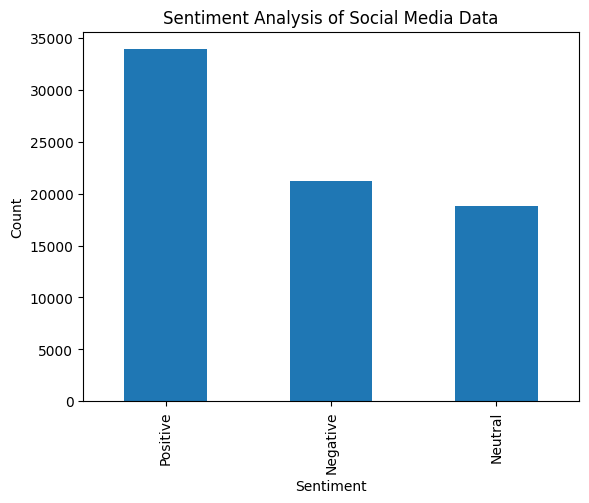

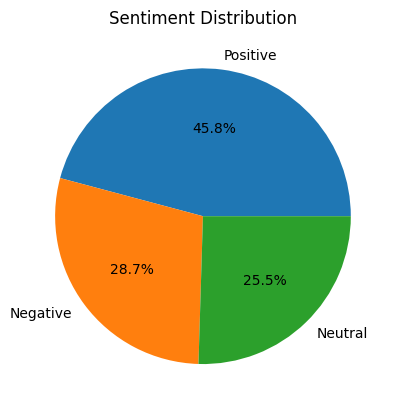

In [ ]:



import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import re


data = pd.read_csv("twitter_training.csv", encoding='latin-1')


data.columns = ['ID', 'Topic', 'Sentiment', 'Text']


data = data.dropna(subset=['Text'])


def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text.lower()

data['Clean_Text'] = data['Text'].apply(clean_text)


def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

data['Predicted_Sentiment'] = data['Clean_Text'].apply(get_sentiment)


sentiment_counts = data['Predicted_Sentiment'].value_counts()


print("Sentiment Counts:\n", sentiment_counts)


plt.figure()
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Analysis of Social Media Data")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


plt.figure()
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()